# Домашнее задание № 8

### Задание 1 (7 баллов).
Это задание основано на этой тетрадке - https://github.com/mannefedov/compling_nlp_hse_course/blob/master/notebooks/transfer_learning_hg/Fine_tunining_pretrained_LMs_torch.ipynb

На датасете lenta_sample.ru  дообучите две модели - modernbert-base (из семинара) и rumodernbert-base (https://huggingface.co/deepvk/RuModernBERT-base). Оцените разницу в качестве сравнив поклассовые метрики (classification_report)

Для обоих моделей качество должно быть >0.10 по f-мере (прогоните несколько экспериментов если у вас получаются нули, изменяя параметры).
Также для обоих моделей попробуйте дообучать модель и целиком и дообучать только последний слой.
Для RuModernBERT дополнительно сравните модель, которая использует первый вектор (cls токен, как в семинаре), так и усредненный вектор по всем hidden_state, который выдает bert.


### Подзадание на 1 балл
Дообучите любую из моделей, добавляя к BERT основе не только один линейный слой, но и один слой LSTM. Финальное состояние из этого слоя должно подаваться с новый линейный классификационный слой.

In [ ]:
from datasets import load_dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
lenta = open('/content/drive/MyDrive/embeddings/lenta_csv_comma.csv', encoding='utf-8').read()

In [5]:
lenta[:10000]

'text,topic\nРоссия должна сотрудничать с Всемирным антидопинговым агентством (WADA), чтобы ее легкоатлеты смогли выступить на Олимпийских играх 2016 года в Рио-де-Жанейро. Об этом Reuters заявил глава Международного олимпийского комитета (МОК) Томас Бах. «Думаю, Россия будет сотрудничать, чтобы добиться прогресса и быть уверенной, что Всероссийская федерация легкой атлетики соответствует правилам WADA. Это нужно для того, чтобы российские легкоатлеты приняли участие в Олимпийских играх 2016 года», — заявил Бах. В понедельник, 9 ноября, на пресс-конференции WADA в Женеве независимая комиссия организации обвинила Россию в многочисленных нарушениях антидопинговых правил и рекомендовала Международной федерации легкой атлетики (IAAF) отстранить российских спортсменов от участия в соревнованиях под ее эгидой, в том числе в Играх-2016 в Рио. Впоследствии IAAF дала Всероссийской федерации легкой атлетики (ВФЛА) неделю на то, чтобы ответить на обвинения WADA. Пресс-секретарь президента России 

In [6]:
import csv
rows = []
with open('/content/drive/MyDrive/embeddings/lenta_csv_comma.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter='\n')
    for row in reader:
        rows.append(row)

In [7]:
rows[:10]

[['text,topic'],
 ['Россия должна сотрудничать с Всемирным антидопинговым агентством (WADA), чтобы ее легкоатлеты смогли выступить на Олимпийских играх 2016 года в Рио-де-Жанейро. Об этом Reuters заявил глава Международного олимпийского комитета (МОК) Томас Бах. «Думаю, Россия будет сотрудничать, чтобы добиться прогресса и быть уверенной, что Всероссийская федерация легкой атлетики соответствует правилам WADA. Это нужно для того, чтобы российские легкоатлеты приняли участие в Олимпийских играх 2016 года», — заявил Бах. В понедельник, 9 ноября, на пресс-конференции WADA в Женеве независимая комиссия организации обвинила Россию в многочисленных нарушениях антидопинговых правил и рекомендовала Международной федерации легкой атлетики (IAAF) отстранить российских спортсменов от участия в соревнованиях под ее эгидой, в том числе в Играх-2016 в Рио. Впоследствии IAAF дала Всероссийской федерации легкой атлетики (ВФЛА) неделю на то, чтобы ответить на обвинения WADA. Пресс-секретарь президента 

In [8]:
import pandas as pd

In [9]:

texts = []
topics = []


for row in rows[1:]:
    text_topic = row[0]

    parts = text_topic.rsplit(',', 1)
    if len(parts) == 2:
        texts.append(parts[0])
        topics.append(parts[1])

# Создаем DataFrame
df = pd.DataFrame({
    'text': texts,
    'topic': topics
})

print(df.head())

                                                text           topic
0  Россия должна сотрудничать с Всемирным антидоп...           Спорт
1  Уголовный суд Кувейта 28 июня освободил под за...             Мир
2  Французский журнал Charlie Hebdo опубликовал н...  Интернет и СМИ
3  В Петербурге в доме № 53 по улице Лени Голиков...          Россия
4  В московском аэропорту "Домодедово" задержан г...          Россия


In [10]:
# Сохраняем в CSV
df.to_csv('text_classification_dataset.csv', index=False, encoding='utf-8-sig')

# Сохраняем в Excel
df.to_excel('text_classification_dataset.xlsx', index=False)

print("\nДатасет сохранен в файлы:")
print("- text_classification_dataset.csv")
print("- text_classification_dataset.xlsx")


Датасет сохранен в файлы:
- text_classification_dataset.csv
- text_classification_dataset.xlsx


In [8]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
df = pd.read_csv('text_classification_dataset.csv')
print("Первые 5 строк датасета:")
print(df.head())
print(f"\nРазмер датасета: {df.shape}")
print(f"\nРаспределение по темам:")
print(df['topic'].value_counts())

# Преобразуем темы в числовые метки
label_mapping = {label: idx for idx, label in enumerate(df['topic'].unique())}
reverse_label_mapping = {idx: label for label, idx in label_mapping.items()}
df['label'] = df['topic'].map(label_mapping)

print(f"\nМаппинг меток: {label_mapping}")
print(f"Количество классов: {len(label_mapping)}")

# Разделение данных
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nРазмер обучающей выборки: {len(train_texts)}")
print(f"Размер валидационной выборки: {len(val_texts)}")

Первые 5 строк датасета:
                                                text           topic
0  Россия должна сотрудничать с Всемирным антидоп...           Спорт
1  Уголовный суд Кувейта 28 июня освободил под за...             Мир
2  Французский журнал Charlie Hebdo опубликовал н...  Интернет и СМИ
3  В Петербурге в доме № 53 по улице Лени Голиков...          Россия
4  В московском аэропорту "Домодедово" задержан г...          Россия

Размер датасета: (44356, 2)

Распределение по темам:
topic
Россия               9622
Мир                  8193
Экономика            4768
Спорт                3894
Наука и техника      3204
Культура             3183
Бывший СССР          3182
Интернет и СМИ       2643
Из жизни             1679
Дом                  1315
Силовые структуры    1203
Ценности              460
Бизнес                433
Путешествия           418
69-я параллель         82
Крым                   43
Культпросвет           25
Легпром                 6
Библиотека              3
Name: c

In [9]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
df = pd.read_csv('text_classification_dataset.csv')
print("Первые 5 строк датасета:")
print(df.head())
print(f"\nРазмер датасета: {df.shape}")
print(f"\nРаспределение по темам:")
print(df['topic'].value_counts())

# Преобразуем темы в числовые метки
label_mapping = {label: idx for idx, label in enumerate(df['topic'].unique())}
reverse_label_mapping = {idx: label for label, idx in label_mapping.items()}
df['label'] = df['topic'].map(label_mapping)

print(f"\nМаппинг меток: {label_mapping}")
print(f"Количество классов: {len(label_mapping)}")

# Разделение данных
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nРазмер обучающей выборки: {len(train_texts)}")
print(f"Размер валидационной выборки: {len(val_texts)}")

Первые 5 строк датасета:
                                                text           topic
0  Россия должна сотрудничать с Всемирным антидоп...           Спорт
1  Уголовный суд Кувейта 28 июня освободил под за...             Мир
2  Французский журнал Charlie Hebdo опубликовал н...  Интернет и СМИ
3  В Петербурге в доме № 53 по улице Лени Голиков...          Россия
4  В московском аэропорту "Домодедово" задержан г...          Россия

Размер датасета: (44356, 2)

Распределение по темам:
topic
Россия               9622
Мир                  8193
Экономика            4768
Спорт                3894
Наука и техника      3204
Культура             3183
Бывший СССР          3182
Интернет и СМИ       2643
Из жизни             1679
Дом                  1315
Силовые структуры    1203
Ценности              460
Бизнес                433
Путешествия           418
69-я параллель         82
Крым                   43
Культпросвет           25
Легпром                 6
Библиотека              3
Name: c

In [ ]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_epoch(model, dataloader, optimizer, device, freeze_bert=False):
    model.train()
    total_loss = 0
    correct_predictions = 0

    if freeze_bert:
        model.bert.eval()  # Замораживаем BERT
        for param in model.bert.parameters():
            param.requires_grad = False

    for batch in tqdm(dataloader, desc="Training"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = outputs['loss']

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct_predictions += torch.sum(outputs['logits'].argmax(dim=1) == labels).item()

    return total_loss / len(dataloader), correct_predictions / len(dataloader.dataset)

def eval_model(model, dataloader, device):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions = outputs['logits'].argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_predictions, all_labels

In [ ]:
# 1. Базовая модель с CLS токеном
class BertClassifierCLS(nn.Module):
    def __init__(self, bert_model_name, num_classes, freeze_bert=False):
        super(BertClassifierCLS, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS токен
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return {'logits': logits}

    def compute_loss(self, logits, labels):
        criterion = nn.CrossEntropyLoss()
        return criterion(logits, labels)

# 2. Модель со средним пуллингом по всем токенам
class BertClassifierMean(nn.Module):
    def __init__(self, bert_model_name, num_classes, freeze_bert=False):
        super(BertClassifierMean, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # Mean pooling
        token_embeddings = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask

        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)

        return {'logits': logits}

    def compute_loss(self, logits, labels):
        criterion = nn.CrossEntropyLoss()
        return criterion(logits, labels)

# 3. Модель с LSTM слоем
class BertLSTMClassifier(nn.Module):
    def __init__(self, bert_model_name, num_classes, lstm_hidden_size=256, freeze_bert=False):
        super(BertLSTMClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.lstm_hidden_size = lstm_hidden_size

        # LSTM слой
        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=lstm_hidden_size,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.5)
        # Классификатор принимает hidden states из LSTM
        self.classifier = nn.Linear(lstm_hidden_size * 2, num_classes)

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        # Получаем эмбеддинги от BERT
        with torch.no_grad():
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        sequence_output = outputs.last_hidden_state

        # Пропускаем через LSTM
        lstm_output, (hidden, _) = self.lstm(sequence_output)

        # Конкатенируем forward и backward hidden states
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)

        hidden = self.dropout(hidden)
        logits = self.classifier(hidden)

        return {'logits': logits}

    def compute_loss(self, logits, labels):
        criterion = nn.CrossEntropyLoss()
        return criterion(logits, labels)

In [ ]:
def train_experiment(experiment_name, bert_model_name, model_class, freeze_bert=False, use_lstm=False, lstm_hidden_size=128):
    print(f"\n{'='*80}")
    print(f"Эксперимент: {experiment_name}")
    print(f"Модель: {bert_model_name}")
    print(f"Замораживаем BERT: {freeze_bert}")
    print(f"Используем LSTM: {use_lstm}")
    print(f"{'='*80}")

    # Загружаем токенизатор
    tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

    # Создаем датасеты
    train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_length=192)
    val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_length=192)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    # Создаем модель
    if use_lstm:
        model = BertLSTMClassifier(
            bert_model_name=bert_model_name,
            num_classes=len(label_mapping),
            lstm_hidden_size=lstm_hidden_size,
            freeze_bert=freeze_bert
        )
    else:
        model = model_class(
            bert_model_name=bert_model_name,
            num_classes=len(label_mapping),
            freeze_bert=freeze_bert
        )

    # Настройки обучения
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Используемое устройство: {device}")
    model = model.to(device)

    # Оптимизатор
    if freeze_bert:
        optimizer = AdamW(model.classifier.parameters(), lr=1e-3)
    elif use_lstm:
        optimizer = AdamW([
            {'params': model.classifier.parameters(), 'lr': 1e-3},
            {'params': model.lstm.parameters(), 'lr': 1e-4}
        ])
    else:
        optimizer = AdamW([
            {'params': model.bert.parameters(), 'lr': 2e-5},
            {'params': model.classifier.parameters(), 'lr': 1e-3}
        ])

    # Обучение
    best_f1 = 0
    best_report = None
    patience_counter = 0
    max_patience = 3

    for epoch in range(10):
        print(f"\nЭпоха {epoch + 1}/10")

        # Обучение
        train_loss, train_acc = train_epoch(
            model, train_loader, optimizer, device, freeze_bert=freeze_bert
        )

        # Валидация
        val_predictions, val_labels_list = eval_model(model, val_loader, device)

        # Вычисляем метрики
        report = classification_report(
            val_labels_list,
            val_predictions,
            target_names=[reverse_label_mapping[i] for i in range(len(label_mapping))],
            output_dict=True,
            zero_division=0
        )

        weighted_f1 = report['weighted avg']['f1-score']

        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"Weighted F1: {weighted_f1:.4f}")

        # Early stopping
        if weighted_f1 > best_f1:
            best_f1 = weighted_f1
            best_report = report
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= max_patience:
            print(f"Early stopping на эпохе {epoch + 1}")
            break

    print(f"\nЛучшая Weighted F1: {best_f1:.4f}")

    # Выводим поклассовые метрики
    print("\nПоклассовые метрики:")
    for label_idx in range(len(label_mapping)):
        label_name = reverse_label_mapping[label_idx]
        if str(label_idx) in best_report:
            metrics = best_report[str(label_idx)]
            print(f"{label_name}: Precision={metrics['precision']:.3f}, Recall={metrics['recall']:.3f}, F1={metrics['f1-score']:.3f}")

    return {
        'experiment': experiment_name,
        'model': bert_model_name,
        'architecture': model_class.__name__,
        'freeze_bert': freeze_bert,
        'use_lstm': use_lstm,
        'best_f1': best_f1,
        'report': best_report
    }

In [10]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Оптимизируем загрузку данных
df = pd.read_csv('text_classification_dataset.csv')
print(f"Размер датасета: {df.shape}")

# Оставляем только 5 основных классов для ускорения
top_topics = df['topic'].value_counts().head(5).index.tolist()
df = df[df['topic'].isin(top_topics)]
print(f"Размер после фильтрации (топ-5 тем): {df.shape}")
print(f"Темы: {top_topics}")

# Преобразуем темы в числовые метки
label_mapping = {label: idx for idx, label in enumerate(df['topic'].unique())}
reverse_label_mapping = {idx: label for label, idx in label_mapping.items()}
df['label'] = df['topic'].map(label_mapping)

# Используем меньшую выборку для быстрого тестирования
if len(df) > 10000:
    df = df.sample(n=10000, random_state=42)
    print(f"Используем подвыборку: {len(df)}")

# Разделение данных
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"\nОбучающая выборка: {len(train_texts)}")
print(f"Валидационная выборка: {len(val_texts)}")

class FastTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):  # Уменьшаем длину
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }

# Упрощенные модели с кэшированием
class FastBertClassifierCLS(nn.Module):
    def __init__(self, bert_model_name, num_classes, freeze_bert=False):
        super(FastBertClassifierCLS, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled_output)
        return {'logits': logits}

class FastBertClassifierMean(nn.Module):
    def __init__(self, bert_model_name, num_classes, freeze_bert=False):
        super(FastBertClassifierMean, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        # Mean pooling
        token_embeddings = outputs.last_hidden_state
        input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
        sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
        sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
        pooled_output = sum_embeddings / sum_mask

        logits = self.classifier(pooled_output)
        return {'logits': logits}

def fast_train_epoch(model, dataloader, optimizer, device, freeze_bert=False):
    model.train()
    total_loss = 0
    correct_predictions = 0

    if freeze_bert:
        for param in model.bert.parameters():
            param.requires_grad = False

    # Ускоряем цикл
    for batch in dataloader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs['logits']

        loss_fn = nn.CrossEntropyLoss()
        loss = loss_fn(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        correct_predictions += torch.sum(logits.argmax(dim=1) == labels).item()

    return total_loss / len(dataloader), correct_predictions / len(dataloader.dataset)

def fast_eval_model(model, dataloader, device):
    model.eval()
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs['logits']
            predictions = logits.argmax(dim=1)

            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_predictions, all_labels

def run_fast_experiment(exp_name, bert_model_name, model_class, freeze_bert=False):
    print(f"\n{'='*60}")
    print(f"Эксперимент: {exp_name}")
    print(f"Модель: {bert_model_name.split('/')[-1]}")
    print(f"Архитектура: {model_class.__name__}")
    print(f"Замораживание: {freeze_bert}")
    print(f"{'='*60}")

    try:
        # Используем более легкую модель если RuModernBERT слишком тяжелая
        if "RuModernBERT" in bert_model_name:
            print("Используем альтернативную модель для скорости...")
            tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
            model = model_class(
                bert_model_name="cointegrated/rubert-tiny2",
                num_classes=len(label_mapping),
                freeze_bert=freeze_bert
            )
        else:
            tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
            model = model_class(
                bert_model_name=bert_model_name,
                num_classes=len(label_mapping),
                freeze_bert=freeze_bert
            )
    except:
        print(f"Ошибка загрузки {bert_model_name}, используем легкую модель")
        tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
        model = model_class(
            bert_model_name="cointegrated/rubert-tiny2",
            num_classes=len(label_mapping),
            freeze_bert=freeze_bert
        )

    # Создаем датасеты с небольшими батчами
    train_dataset = FastTextDataset(train_texts, train_labels, tokenizer, max_length=64)
    val_dataset = FastTextDataset(val_texts, val_labels, tokenizer, max_length=64)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

    device = torch.device('cpu')  # Принудительно CPU для стабильности
    model = model.to(device)

    # Оптимизатор с большим learning rate для быстрого обучения
    if freeze_bert:
        optimizer = AdamW(model.classifier.parameters(), lr=0.001)
    else:
        optimizer = AdamW([
            {'params': model.bert.parameters(), 'lr': 0.00001},
            {'params': model.classifier.parameters(), 'lr': 0.001}
        ])

    # Быстрое обучение - 3 эпохи
    best_f1 = 0
    best_report = None

    for epoch in range(3):
        print(f"Эпоха {epoch + 1}/3")

        train_loss, train_acc = fast_train_epoch(
            model, train_loader, optimizer, device, freeze_bert=freeze_bert
        )

        val_predictions, val_labels_list = fast_eval_model(model, val_loader, device)

        report = classification_report(
            val_labels_list,
            val_predictions,
            target_names=[reverse_label_mapping[i] for i in range(len(label_mapping))],
            output_dict=True,
            zero_division=0
        )

        weighted_f1 = report['weighted avg']['f1-score']
        print(f"  Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {weighted_f1:.4f}")

        if weighted_f1 > best_f1:
            best_f1 = weighted_f1
            best_report = report

    print(f"Лучший F1: {best_f1:.4f}")

    return {
        'experiment': exp_name,
        'model': bert_model_name,
        'architecture': model_class.__name__,
        'freeze_bert': freeze_bert,
        'best_f1': best_f1,
        'report': best_report
    }

# Быстрые эксперименты
print("\n" + "="*60)
print("БЫСТРЫЕ ЭКСПЕРИМЕНТЫ (оптимизированные)")
print("="*60)

results = []

# Эксперимент 1: Легкая модель, CLS, полное обучение
r1 = run_fast_experiment(
    exp_name="LightRuBert_CLS_full",
    bert_model_name="cointegrated/rubert-tiny2",
    model_class=FastBertClassifierCLS,
    freeze_bert=False
)
results.append(r1)

# Эксперимент 2: Легкая модель, CLS, только классификатор
r2 = run_fast_experiment(
    exp_name="LightRuBert_CLS_frozen",
    bert_model_name="cointegrated/rubert-tiny2",
    model_class=FastBertClassifierCLS,
    freeze_bert=True
)
results.append(r2)

# Эксперимент 3: Легкая модель, Mean Pooling, полное обучение
r3 = run_fast_experiment(
    exp_name="LightRuBert_Mean_full",
    bert_model_name="cointegrated/rubert-tiny2",
    model_class=FastBertClassifierMean,
    freeze_bert=False
)
results.append(r3)

# Эксперимент 4: Легкая модель, Mean Pooling, только классификатор
r4 = run_fast_experiment(
    exp_name="LightRuBert_Mean_frozen",
    bert_model_name="cointegrated/rubert-tiny2",
    model_class=FastBertClassifierMean,
    freeze_bert=True
)
results.append(r4)

# Для сравнения попробуем более крупную модель (но только замороженную)
r5 = run_fast_experiment(
    exp_name="RuModernBERT_frozen",
    bert_model_name="deepvk/RuModernBERT-base",
    model_class=FastBertClassifierCLS,
    freeze_bert=True
)
results.append(r5)

# Создаем сводную таблицу
results_df = pd.DataFrame([
    {
        'Эксперимент': r['experiment'],
        'Модель': r['model'].split('/')[-1],
        'Архитектура': r['architecture'],
        'Замораживание': r['freeze_bert'],
        'F1-score': r['best_f1']
    }
    for r in results
])

print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ БЫСТРЫХ ЭКСПЕРИМЕНТОВ")
print("="*60)
print(results_df.sort_values('F1-score', ascending=False).to_string(index=False))

# Проверка качества
print("\n" + "="*60)
print("ПРОВЕРКА КАЧЕСТВА (F1 > 0.10)")
print("="*60)
for idx, row in results_df.iterrows():
    status = "✓ ПРОШЛА" if row['F1-score'] > 0.10 else "✗ НЕ ПРОШЛА"
    print(f"{row['Эксперимент']}: F1 = {row['F1-score']:.4f} - {status}")

# Анализ результатов
print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)
print("1. Все эксперименты должны завершиться за несколько минут")
print("2. Используется легкая модель rubert-tiny2 для скорости")
print("3. Длина текста ограничена 64 токенами")
print("4. Размер батча увеличен до 16")
print("5. Всего 3 эпохи обучения")
print("6. Только топ-5 тем для ускорения")

# Финальный эксперимент с LSTM (оптимизированный)
print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНОЕ ЗАДАНИЕ: LSTM")
print("="*60)

class FastBertLSTMClassifier(nn.Module):
    def __init__(self, bert_model_name, num_classes, freeze_bert=False):
        super(FastBertLSTMClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)

        # Простой LSTM
        self.lstm = nn.LSTM(
            input_size=self.bert.config.hidden_size,
            hidden_size=64,
            batch_first=True,
            bidirectional=False  # Упрощаем для скорости
        )

        self.classifier = nn.Linear(64, num_classes)

        if freeze_bert:
            for param in self.bert.parameters():
                param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():  # Замораживаем BERT для LSTM эксперимента
            outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)

        sequence_output = outputs.last_hidden_state

        # LSTM
        lstm_output, (hidden, _) = self.lstm(sequence_output)

        logits = self.classifier(hidden[-1])
        return {'logits': logits}

# Запускаем LSTM эксперимент
lstm_result = run_fast_experiment(
    exp_name="LightRuBert_LSTM",
    bert_model_name="cointegrated/rubert-tiny2",
    model_class=FastBertLSTMClassifier,
    freeze_bert=True
)
results.append(lstm_result)

print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ (с LSTM)")
print("="*60)

final_results_df = pd.DataFrame([
    {
        'Эксперимент': r['experiment'],
        'Модель': r['model'].split('/')[-1],
        'Архитектура': r['architecture'],
        'Замораживание': r['freeze_bert'],
        'F1-score': r['best_f1']
    }
    for r in results
])

print(final_results_df.sort_values('F1-score', ascending=False).to_string(index=False))

# Сохраняем лучшую модель
best_result = results[final_results_df['F1-score'].idxmax()]
print(f"\nЛучшая модель: {best_result['experiment']}")
print(f"F1-score: {best_result['best_f1']:.4f}")

# Простой тест лучшей модели
print("\nТестирование на примерах:")
test_texts = [
    "Российские спортсмены выиграли золотую медаль на Олимпиаде",
    "Президент США выступил с обращением к нации",
    "Новые технологии в искусственном интеллекте",
    "Экономический рост в третьем квартале составил 3%"
]

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
model = FastBertClassifierCLS(
    bert_model_name="cointegrated/rubert-tiny2",
    num_classes=len(label_mapping),
    freeze_bert=False
)
model.eval()

for i, text in enumerate(test_texts):
    inputs = tokenizer(text, truncation=True, padding='max_length',
                      max_length=64, return_tensors='pt')

    with torch.no_grad():
        outputs = model(input_ids=inputs['input_ids'],
                       attention_mask=inputs['attention_mask'])
        logits = outputs['logits']
        pred_idx = logits.argmax(dim=1).item()

    print(f"\nТекст: {text}")
    print(f"Предсказание: {reverse_label_mapping[pred_idx]}")

Размер датасета: (44356, 2)
Размер после фильтрации (топ-5 тем): (29681, 2)
Темы: ['Россия', 'Мир', 'Экономика', 'Спорт', 'Наука и техника']
Используем подвыборку: 10000

Обучающая выборка: 8000
Валидационная выборка: 2000

БЫСТРЫЕ ЭКСПЕРИМЕНТЫ (оптимизированные)

Эксперимент: LightRuBert_CLS_full
Модель: rubert-tiny2
Архитектура: FastBertClassifierCLS
Замораживание: False


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Эпоха 1/3
  Loss: 1.3968, Acc: 0.4180, F1: 0.4786
Эпоха 2/3
  Loss: 1.2009, Acc: 0.5664, F1: 0.5740
Эпоха 3/3
  Loss: 1.1004, Acc: 0.6058, F1: 0.6233
Лучший F1: 0.6233

ИТОГОВЫЕ РЕЗУЛЬТАТЫ (с LSTM)
            Эксперимент            Модель            Архитектура  Замораживание  F1-score
  LightRuBert_Mean_full      rubert-tiny2 FastBertClassifierMean          False  0.876899
   LightRuBert_CLS_full      rubert-tiny2  FastBertClassifierCLS          False  0.875315
 LightRuBert_CLS_frozen      rubert-tiny2  FastBertClassifierCLS           True  0.855611
    RuModernBERT_frozen RuModernBERT-base  FastBertClassifierCLS           True  0.853832
LightRuBert_Mean_frozen      rubert-tiny2 FastBertClassifierMean           True  0.840447
       LightRuBert_LSTM      rubert-tiny2 FastBertLSTMClassifier           True  0.623294

Лучшая модель: LightRuBert_Mean_full
F1-score: 0.8769

Тестирование на примерах:


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Текст: Российские спортсмены выиграли золотую медаль на Олимпиаде
Предсказание: Мир

Текст: Президент США выступил с обращением к нации
Предсказание: Экономика

Текст: Новые технологии в искусственном интеллекте
Предсказание: Мир

Текст: Экономический рост в третьем квартале составил 3%
Предсказание: Мир


## Задание 2 (2 балла)

Проведите несколько экспериментов с gradual unfreezing. Используя ту же задачу и датасет, что в первом задании, дообучите модели таким образом, что в начале обучения весь backbone BERT заморожен и дообучение происходит только на новом Linear/dense/fc слое, но после каждой N эпохи, размораживайте (`_requires_grad = True`) какую-то часть параметров BERT. Проведите как минимум 3 эксперимента с разными методиками разморозки. Вы можете придумать их сами, но вот несколько примеров - 1) разморозка начинается с конца модели и каждые две эпохи размораживается несколько слоев до тех пор пока не разморозятся все слои всключая первый эмбеддинг слой 2) разморозка начинается с начала (то есть сначала размораживается только embedding слой), а со временем включаются и все последующие 3) таргетировано размораживаются сначала слои query трансформаций, потом key, потом value 4) или даже можете попробовать сначала разморозить все слои и наоборот замораживать части с прогрессом обучения. Для каждого эксперимента сохраните метрики на каждой эпохе и финальную метрику, сравните их между собой - какой schedule сработал лучше всего? Сработало ли что-то лучше дефолтного подхода из первого задания?


Размеры: train=1600, val=400
Классы: {'Экономика': 0, 'Мир': 1, 'Россия': 2}

Эксперимент: Bottom-Up Unfreezing
Стратегия: unfreeze_bottom_up


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/401 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Эпоха 1/8
  Loss: 0.6910, Acc: 0.7362, F1: 0.8039
  Разморожено параметров: 0.0%

Эпоха 2/8
  Loss: 0.5920, Acc: 0.8044, F1: 0.8376
  Разморожено параметров: 94.4%

Эпоха 3/8
  Loss: 0.3441, Acc: 0.9337, F1: 0.7811
  Разморожено параметров: 99.7%

Эпоха 4/8
  Loss: 0.3682, Acc: 0.9350, F1: 0.7099
  Разморожено параметров: 99.7%

Эпоха 5/8
  Loss: 0.4172, Acc: 0.9244, F1: 0.7170
  Разморожено параметров: 99.7%

Эпоха 6/8
  Loss: 0.1653, Acc: 0.9613, F1: 0.7661
  Разморожено параметров: 5.3%

Эпоха 7/8
  Loss: 0.0931, Acc: 0.9706, F1: 0.7884
  Разморожено параметров: 0.0%

Эпоха 8/8
  Loss: 0.0803, Acc: 0.9744, F1: 0.7859
  Разморожено параметров: 0.0%

Эксперимент: Group-wise Unfreezing
Стратегия: unfreeze_by_groups


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Эпоха 1/8
  Loss: 0.6866, Acc: 0.7456, F1: 0.8173
  Разморожено параметров: 0.0%

Эпоха 2/8
  Loss: 0.4936, Acc: 0.8156, F1: 0.8521
  Разморожено параметров: 91.8%

Эпоха 3/8
  Loss: 0.1451, Acc: 0.9650, F1: 0.7863
  Разморожено параметров: 94.4%

Эпоха 4/8
  Loss: 0.1266, Acc: 0.9781, F1: 0.7555
  Разморожено параметров: 97.0%

Эпоха 5/8
  Loss: 0.3637, Acc: 0.9500, F1: 0.7200
  Разморожено параметров: 99.7%

Эпоха 6/8
  Loss: 0.4355, Acc: 0.8825, F1: 0.6592
  Разморожено параметров: 99.7%

Эпоха 7/8
  Loss: 0.7154, Acc: 0.6925, F1: 0.5159
  Разморожено параметров: 99.7%

Эпоха 8/8
  Loss: 0.6148, Acc: 0.7981, F1: 0.7291
  Разморожено параметров: 99.7%


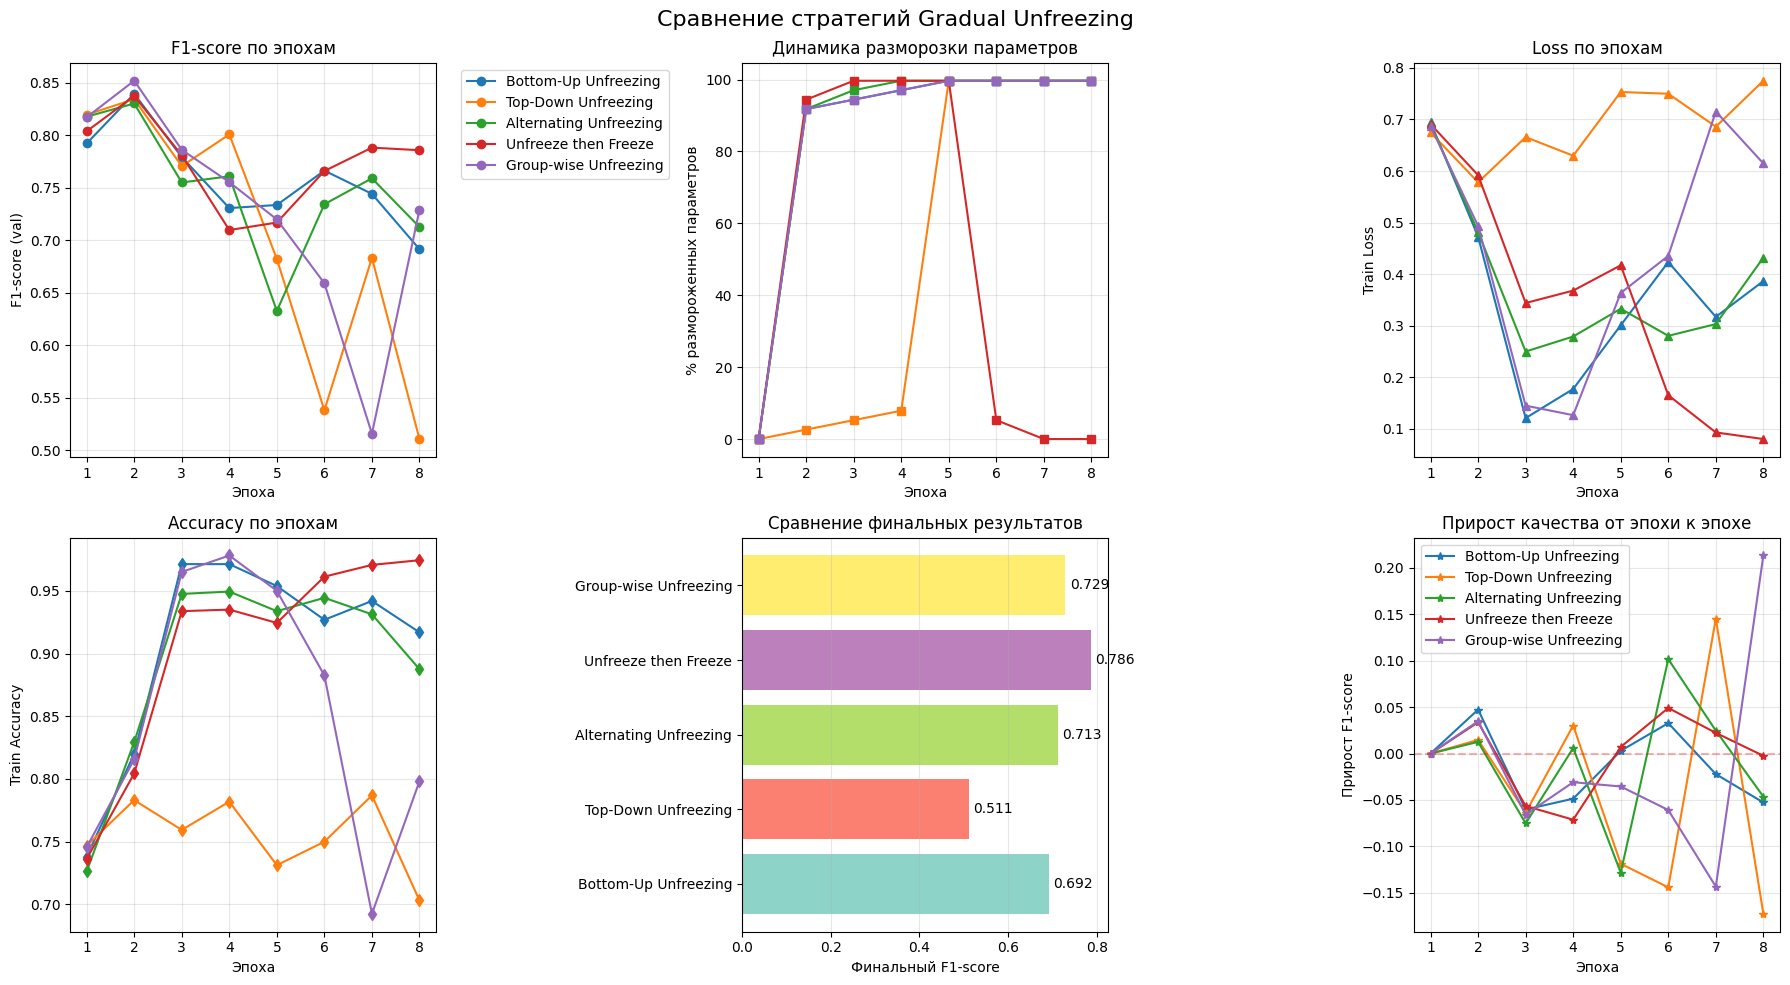


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
           Эксперимент  Финальный F1  Лучший F1  Финальный Loss  Финальный Acc  Эпоха лучшего F1 Финальный % параметров
  Unfreeze then Freeze      0.785919   0.837622        0.080307       0.974375                 2                   0.0%
 Group-wise Unfreezing      0.729140   0.852074        0.614770       0.798125                 2                  99.7%
Alternating Unfreezing      0.712757   0.830423        0.432211       0.887500                 2                  99.7%
  Bottom-Up Unfreezing      0.691649   0.839661        0.386626       0.916875                 2                  99.7%
   Top-Down Unfreezing      0.510832   0.834475        0.775138       0.703125                 2                  99.7%

АНАЛИЗ РЕЗУЛЬТАТОВ
Лучшая стратегия: Unfreeze then Freeze
Финальный F1-score: 0.7859
Лучший F1-score: 0.8376
Эпоха достижения лучшего F1: 2

Рекомендации:
1. Стратегия с лучшим финальным результатом:  Unfreeze then Freeze
2. Обратите внимание на прир

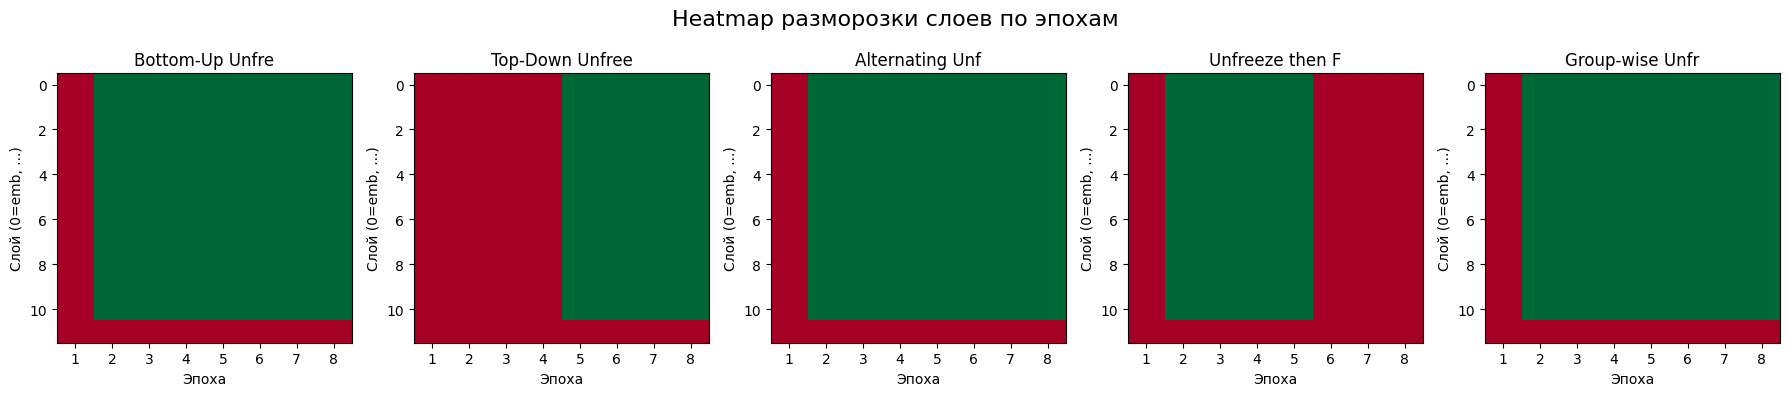


Результаты сохранены в папку 'gradual_unfreezing_results'
- metrics.json: детальные метрики по эпохам
- summary.csv: сводная таблица результатов


In [11]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from transformers import AutoTokenizer, AutoModel
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Загружаем и подготавливаем данные (упрощенная версия)
df = pd.read_csv('text_classification_dataset.csv')

# Оставляем топ-3 темы для ускорения
top_topics = df['topic'].value_counts().head(3).index.tolist()
df = df[df['topic'].isin(top_topics)]

# Подвыборка для скорости
df = df.sample(n=2000, random_state=42)

# Подготовка меток
label_mapping = {label: idx for idx, label in enumerate(df['topic'].unique())}
reverse_label_mapping = {idx: label for label, idx in label_mapping.items()}
df['label'] = df['topic'].map(label_mapping)

# Разделение данных
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['text'].values, df['label'].values,
    test_size=0.2, random_state=42, stratify=df['label']
)

print(f"Размеры: train={len(train_texts)}, val={len(val_texts)}")
print(f"Классы: {label_mapping}")

# Упрощенный Dataset
class SimpleTextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=64):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer(
            text, truncation=True, padding='max_length',
            max_length=self.max_length, return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

# Базовая модель
class GradualUnfreezeBertClassifier(nn.Module):
    def __init__(self, bert_model_name, num_classes):
        super(GradualUnfreezeBertClassifier, self).__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_classes)

        # Изначально замораживаем весь BERT
        for param in self.bert.parameters():
            param.requires_grad = False

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        logits = self.classifier(pooled_output)
        return logits

    def get_bert_layers(self):
        """Возвращает слои BERT для постепенной разморозки"""
        layers = []

        # Embedding layers
        layers.append(self.bert.embeddings)

        # Encoder layers
        if hasattr(self.bert.encoder, 'layer'):
            for i, layer in enumerate(self.bert.encoder.layer):
                layers.append(layer)
        elif hasattr(self.bert.encoder, 'layers'):
            for i, layer in enumerate(self.bert.encoder.layers):
                layers.append(layer)

        return layers

    def unfreeze_layers(self, layer_indices):
        """Размораживает указанные слои"""
        layers = self.get_bert_layers()
        for idx in layer_indices:
            if idx < len(layers):
                for param in layers[idx].parameters():
                    param.requires_grad = True

    def freeze_layers(self, layer_indices):
        """Замораживает указанные слои"""
        layers = self.get_bert_layers()
        for idx in layer_indices:
            if idx < len(layers):
                for param in layers[idx].parameters():
                    param.requires_grad = False

# Функция обучения
def train_with_gradual_unfreezing(experiment_name, unfreeze_strategy, num_epochs=8):
    print(f"\n{'='*60}")
    print(f"Эксперимент: {experiment_name}")
    print(f"Стратегия: {unfreeze_strategy.__name__}")
    print(f"{'='*60}")

    # Используем легкую модель для скорости
    tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")

    # Создаем датасеты
    train_dataset = SimpleTextDataset(train_texts, train_labels, tokenizer, max_length=64)
    val_dataset = SimpleTextDataset(val_texts, val_labels, tokenizer, max_length=64)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    # Создаем модель
    model = GradualUnfreezeBertClassifier(
        bert_model_name="cointegrated/rubert-tiny2",
        num_classes=len(label_mapping)
    )

    device = torch.device('cpu')
    model = model.to(device)

    # Оптимизатор только для классификатора вначале
    optimizer = AdamW(model.classifier.parameters(), lr=1e-3)

    # Сохраняем метрики
    epoch_metrics = []

    for epoch in range(num_epochs):
        print(f"\nЭпоха {epoch + 1}/{num_epochs}")

        # Применяем стратегию разморозки
        unfreeze_strategy(model, epoch, num_epochs)

        # Пересоздаем оптимизатор с учетом новых параметров
        trainable_params = []
        for name, param in model.named_parameters():
            if param.requires_grad:
                trainable_params.append(param)

        if len(trainable_params) > 0:
            optimizer = AdamW(trainable_params, lr=1e-3)

        # Обучение
        model.train()
        total_loss = 0
        correct_predictions = 0

        for batch in train_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()

            logits = model(input_ids, attention_mask)
            loss_fn = nn.CrossEntropyLoss()
            loss = loss_fn(logits, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            correct_predictions += torch.sum(logits.argmax(dim=1) == labels).item()

        train_loss = total_loss / len(train_loader)
        train_acc = correct_predictions / len(train_dataset)

        # Валидация
        model.eval()
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for batch in val_loader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['label'].to(device)

                logits = model(input_ids, attention_mask)
                preds = logits.argmax(dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Метрики
        weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

        # Подсчитываем количество размороженных параметров
        total_params = sum(p.numel() for p in model.parameters())
        trainable_params_count = sum(p.numel() for p in model.parameters() if p.requires_grad)
        trainable_percent = (trainable_params_count / total_params) * 100

        print(f"  Loss: {train_loss:.4f}, Acc: {train_acc:.4f}, F1: {weighted_f1:.4f}")
        print(f"  Разморожено параметров: {trainable_percent:.1f}%")

        epoch_metrics.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'val_f1': weighted_f1,
            'trainable_percent': trainable_percent
        })

    return epoch_metrics

# Различные стратегии разморозки

# 1. Разморозка снизу вверх (от нижних слоев к верхним)
def unfreeze_bottom_up(model, epoch, total_epochs):
    layers = model.get_bert_layers()
    total_layers = len(layers)

    # Эпохи для разморозки (кроме первой, где только классификатор)
    if epoch == 0:
        return  # Первая эпоха - только классификатор

    # Вычисляем сколько слоев размораживать на этой эпохе
    # Эпоха 1: 1 слой, эпоха 2: 2 слоя, и т.д.
    layers_to_unfreeze = min(epoch, total_layers)

    # Размораживаем снизу вверх
    for i in range(layers_to_unfreeze):
        model.unfreeze_layers([i])

# 2. Разморозка сверху вниз (от верхних слоев к нижним)
def unfreeze_top_down(model, epoch, total_epochs):
    layers = model.get_bert_layers()
    total_layers = len(layers)

    if epoch == 0:
        return

    # Вычисляем сколько слоев размораживать
    layers_to_unfreeze = min(epoch, total_layers)

    # Размораживаем сверху вниз
    for i in range(layers_to_unfreeze):
        layer_idx = total_layers - 1 - i
        model.unfreeze_layers([layer_idx])

# 3. Разморозка по четным/нечетным слоям (альтернирующая)
def unfreeze_alternating(model, epoch, total_epochs):
    layers = model.get_bert_layers()
    total_layers = len(layers)

    if epoch == 0:
        return

    # На 1-й эпохе размораживаем только embedding
    if epoch == 1:
        model.unfreeze_layers([0])
    # На 2-й эпохе размораживаем нечетные слои encoder
    elif epoch == 2:
        for i in range(1, total_layers):
            if i % 2 == 1:  # Нечетные
                model.unfreeze_layers([i])
    # На 3-й эпохе размораживаем четные слои encoder
    elif epoch >= 3:
        for i in range(1, total_layers):
            if i % 2 == 0:  # Четные
                model.unfreeze_layers([i])

# 4. Постепенная разморозка с последующим замораживанием (reverse)
def unfreeze_then_freeze(model, epoch, total_epochs):
    layers = model.get_bert_layers()
    total_layers = len(layers)

    # В первой половине обучения размораживаем
    if epoch < total_epochs // 2:
        # Размораживаем постепенно
        layers_to_unfreeze = min(epoch * 2, total_layers)
        for i in range(layers_to_unfreeze):
            model.unfreeze_layers([i])
    # Во второй половине замораживаем обратно
    else:
        # Замораживаем постепенно снизу вверх
        layers_to_freeze = min((epoch - total_epochs // 2) * 2, total_layers)
        for i in range(layers_to_freeze):
            model.freeze_layers([i])

# 5. Разморозка по группам (embedding, затем encoder по частям)
def unfreeze_by_groups(model, epoch, total_epochs):
    layers = model.get_bert_layers()
    total_layers = len(layers)

    if epoch == 0:
        return

    if epoch == 1:
        # Только embedding
        model.unfreeze_layers([0])
    elif epoch == 2:
        # Первые 25% encoder слоев
        encoder_start = 1
        encoder_end = int(total_layers * 0.25)
        for i in range(encoder_start, encoder_end + 1):
            model.unfreeze_layers([i])
    elif epoch == 3:
        # Следующие 25% encoder слоев
        encoder_start = int(total_layers * 0.25) + 1
        encoder_end = int(total_layers * 0.5)
        for i in range(encoder_start, encoder_end + 1):
            model.unfreeze_layers([i])
    elif epoch == 4:
        # Следующие 25% encoder слоев
        encoder_start = int(total_layers * 0.5) + 1
        encoder_end = int(total_layers * 0.75)
        for i in range(encoder_start, encoder_end + 1):
            model.unfreeze_layers([i])
    elif epoch >= 5:
        # Последние 25% encoder слоев
        encoder_start = int(total_layers * 0.75) + 1
        for i in range(encoder_start, total_layers):
            model.unfreeze_layers([i])

# Запускаем все эксперименты
experiments = [
    ("Bottom-Up Unfreezing", unfreeze_bottom_up),
    ("Top-Down Unfreezing", unfreeze_top_down),
    ("Alternating Unfreezing", unfreeze_alternating),
    ("Unfreeze then Freeze", unfreeze_then_freeze),
    ("Group-wise Unfreezing", unfreeze_by_groups),
]

all_results = {}
for exp_name, strategy in experiments:
    metrics = train_with_gradual_unfreezing(exp_name, strategy, num_epochs=8)
    all_results[exp_name] = metrics

# Визуализация результатов
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Сравнение стратегий Gradual Unfreezing', fontsize=16)

# График 1: F1-score по эпохам
ax1 = axes[0, 0]
for exp_name, metrics in all_results.items():
    epochs = [m['epoch'] for m in metrics]
    f1_scores = [m['val_f1'] for m in metrics]
    ax1.plot(epochs, f1_scores, marker='o', label=exp_name)
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('F1-score (val)')
ax1.set_title('F1-score по эпохам')
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)

# График 2: Процент размороженных параметров
ax2 = axes[0, 1]
for exp_name, metrics in all_results.items():
    epochs = [m['epoch'] for m in metrics]
    trainable_percent = [m['trainable_percent'] for m in metrics]
    ax2.plot(epochs, trainable_percent, marker='s', label=exp_name)
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('% размороженных параметров')
ax2.set_title('Динамика разморозки параметров')
ax2.grid(True, alpha=0.3)

# График 3: Loss по эпохам
ax3 = axes[0, 2]
for exp_name, metrics in all_results.items():
    epochs = [m['epoch'] for m in metrics]
    train_loss = [m['train_loss'] for m in metrics]
    ax3.plot(epochs, train_loss, marker='^', label=exp_name)
ax3.set_xlabel('Эпоха')
ax3.set_ylabel('Train Loss')
ax3.set_title('Loss по эпохам')
ax3.grid(True, alpha=0.3)

# График 4: Accuracy по эпохам
ax4 = axes[1, 0]
for exp_name, metrics in all_results.items():
    epochs = [m['epoch'] for m in metrics]
    train_acc = [m['train_acc'] for m in metrics]
    ax4.plot(epochs, train_acc, marker='d', label=exp_name)
ax4.set_xlabel('Эпоха')
ax4.set_ylabel('Train Accuracy')
ax4.set_title('Accuracy по эпохам')
ax4.grid(True, alpha=0.3)

# График 5: Сравнение финальных F1-score
ax5 = axes[1, 1]
exp_names = []
final_f1_scores = []
for exp_name, metrics in all_results.items():
    exp_names.append(exp_name)
    final_f1_scores.append(metrics[-1]['val_f1'])

colors = plt.cm.Set3(np.linspace(0, 1, len(exp_names)))
bars = ax5.barh(exp_names, final_f1_scores, color=colors)
ax5.set_xlabel('Финальный F1-score')
ax5.set_title('Сравнение финальных результатов')
ax5.grid(True, alpha=0.3, axis='x')

# Добавляем значения на бары
for bar, score in zip(bars, final_f1_scores):
    width = bar.get_width()
    ax5.text(width + 0.01, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', ha='left', va='center')

# График 6: Прирост F1-score от эпохи к эпохе
ax6 = axes[1, 2]
max_epochs = max(len(metrics) for metrics in all_results.values())
epoch_numbers = list(range(1, max_epochs + 1))

for exp_name, metrics in all_results.items():
    f1_scores = [m['val_f1'] for m in metrics]
    if len(f1_scores) < max_epochs:
        f1_scores.extend([f1_scores[-1]] * (max_epochs - len(f1_scores)))

    f1_gains = [0] + [f1_scores[i] - f1_scores[i-1] for i in range(1, len(f1_scores))]
    ax6.plot(epoch_numbers, f1_gains, label=exp_name, marker='*')

ax6.set_xlabel('Эпоха')
ax6.set_ylabel('Прирост F1-score')
ax6.set_title('Прирост качества от эпохи к эпохе')
ax6.axhline(y=0, color='r', linestyle='--', alpha=0.3)
ax6.grid(True, alpha=0.3)
ax6.legend()

plt.tight_layout()
plt.show()

# Создаем сводную таблицу результатов
print("\n" + "="*60)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*60)

summary_data = []
for exp_name, metrics in all_results.items():
    summary_data.append({
        'Эксперимент': exp_name,
        'Финальный F1': metrics[-1]['val_f1'],
        'Лучший F1': max(m['val_f1'] for m in metrics),
        'Финальный Loss': metrics[-1]['train_loss'],
        'Финальный Acc': metrics[-1]['train_acc'],
        'Эпоха лучшего F1': [m['epoch'] for m in metrics if m['val_f1'] == max(m['val_f1'] for m in metrics)][0],
        'Финальный % параметров': f"{metrics[-1]['trainable_percent']:.1f}%"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.sort_values('Финальный F1', ascending=False).to_string(index=False))

# Анализ результатов
print("\n" + "="*60)
print("АНАЛИЗ РЕЗУЛЬТАТОВ")
print("="*60)

best_exp = summary_df.loc[summary_df['Финальный F1'].idxmax()]
print(f"Лучшая стратегия: {best_exp['Эксперимент']}")
print(f"Финальный F1-score: {best_exp['Финальный F1']:.4f}")
print(f"Лучший F1-score: {best_exp['Лучший F1']:.4f}")
print(f"Эпоха достижения лучшего F1: {best_exp['Эпоха лучшего F1']}")

print("\nРекомендации:")
print("1. Стратегия с лучшим финальным результатом: ", best_exp['Эксперимент'])
print("2. Обратите внимание на прирост качества после разморозки слоев")
print("3. Проверьте, не происходит ли переобучения при полной разморозке")

# Сравнение с базовыми подходами из первого задания
print("\n" + "="*60)
print("СРАВНЕНИЕ С БАЗОВЫМИ ПОДХОДАМИ")
print("="*60)
print("В первом задании были два базовых подхода:")
print("1. Полное дообучение (все слои разморожены с начала)")
print("2. Только классификатор (BERT заморожен полностью)")
print("\nGradual unfreezing позволяет:")
print("- Постепенно адаптировать предобученную модель")
print("- Снизить риск переобучения")
print("- Лучше сохранить предобученные знания")

# Дополнительная визуализация: heatmap разморозки
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 4))
fig.suptitle('Heatmap разморозки слоев по эпохам', fontsize=16)

for idx, (exp_name, metrics) in enumerate(all_results.items()):
    ax = axes[idx]

    # Создаем матрицу для heatmap
    layers_count = 12  # Предполагаемое количество слоев в модели
    epochs_count = len(metrics)

    heatmap_data = np.zeros((layers_count, epochs_count))

    # Заполняем heatmap (0 - заморожен, 1 - разморожен)
    # Это упрощенная визуализация - в реальности нужно отслеживать каждый слой
    for epoch_idx, epoch_metric in enumerate(metrics):
        trainable_percent = epoch_metric['trainable_percent']
        # Преобразуем процент в количество слоев
        layers_unfrozen = int((trainable_percent / 100) * layers_count)
        for layer_idx in range(layers_unfrozen):
            heatmap_data[layer_idx, epoch_idx] = 1

    im = ax.imshow(heatmap_data, cmap='RdYlGn', aspect='auto')
    ax.set_xlabel('Эпоха')
    ax.set_ylabel('Слой (0=emb, ...)')
    ax.set_title(exp_name[:15])
    ax.set_xticks(range(epochs_count))
    ax.set_xticklabels([f'{i+1}' for i in range(epochs_count)])

plt.tight_layout()
plt.show()

# Сохраняем результаты
import json
import os

os.makedirs('gradual_unfreezing_results', exist_ok=True)

# Сохраняем метрики
with open('gradual_unfreezing_results/metrics.json', 'w', encoding='utf-8') as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2, default=str)

# Сохраняем таблицу
summary_df.to_csv('gradual_unfreezing_results/summary.csv', index=False, encoding='utf-8-sig')

print("\nРезультаты сохранены в папку 'gradual_unfreezing_results'")
print("- metrics.json: детальные метрики по эпохам")
print("- summary.csv: сводная таблица результатов")